In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import re,sys,os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib

# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

# Optional: Set PDF to embed fonts (for Illustrator editing)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for better editing

In [3]:
DATA_DIR = Path(r"F:\lab\cptac_prostate\data\v4\CPTAC")
OUTPUT_DIR = Path(r"E:\lab\cptac-prostate\runs\20260402_frag_cptac_tmt_pca")
OUTPUT_DIR.mkdir(exist_ok=True)
print(DATA_DIR.exists(), OUTPUT_DIR.exists())
meta_path = DATA_DIR / "20_MetaData_03_12_2026.csv"

True True


In [4]:
meta = pd.read_csv(meta_path)
meta

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.342000,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.281000,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.420000,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.000000,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR


In [5]:
meta_include = meta[meta["include_or_excludetumor"] == "Include"]
meta_include

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.342000,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.281000,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.420000,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.000000,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR


In [6]:
sample_id_col = "common_ID"
purity_map = dict(zip(meta_include[sample_id_col], meta_include["FirstCategory"]))
stage_map = dict(zip(meta_include[sample_id_col], meta_include["stage"]))
gleason_map = dict(zip(meta_include[sample_id_col], meta_include["Grade_Group"]))

In [7]:
meta_exclude = meta[meta["include_or_excludetumor"] == "exclude"]
meta_exclude

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
144,C3L-09492,C3L.09492.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145,C3L-09497,C3L.09497.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146,C3L-06260,C3L.06260.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
147,C3L-06510,C3L.06510.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,C3L-07890,C3L.07890.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,C3L-09372,C3L.09372.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,C3N-09047,C3N.09047.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,C3L-07868,C3L.07868.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,C3L-09563,C3L.09563.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,C3L-10319,C3L.10319.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
meta_normal = meta[meta["include_or_excludetumor"] == "normal"]
meta_normal

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
111,C3L-07813,C3L.07813.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112,C3L-06504,C3L.06504.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,C3L-06506,C3L.06506.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114,C3L-06741,C3L.06741.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,C3L-06890,C3L.06890.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,C3L-06901,C3L.06901.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,C3L-06743,C3L.06743.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118,C3L-07607,C3L.07607.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,C3L-06436,C3L.06436.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,C3L-07809,C3L.07809.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
tumors_included = meta_include['common_ID'].tolist()
tumors_excluded = meta_exclude['common_ID'].tolist()
print(len(tumors_included), len(tumors_excluded))

134 16


In [10]:
normals = meta_normal['common_ID'].tolist()
print(len(normals))

33


In [11]:
# data
files = [i for i in DATA_DIR.iterdir() if i.is_file()]
files = [i for i in files if re.search(r"pY_TMT_ratio",i.stem, re.IGNORECASE) \
         and not re.search(r"tumor_purity_corrected",i.stem, re.IGNORECASE) \
            and re.search(r"normalized",i.stem, re.IGNORECASE) ]
data_path = files[0]
print(data_path)
header_cols = ["gene_site","Index","SequenceWindow"]
data = pd.read_csv(data_path,sep="\t").set_index(header_cols)
data_nomiss = data.dropna()

F:\lab\cptac_prostate\data\v4\CPTAC\prostate_CPTAC_normalized_pY_TMT_ratio_single_site_MD.tsv


In [12]:
files

[WindowsPath('F:/lab/cptac_prostate/data/v4/CPTAC/prostate_CPTAC_normalized_pY_TMT_ratio_single_site_MD.tsv')]

In [13]:
data

,,,C3L.05292.T,C3L.09383.T,CHTN.43798.T,C3L.06261.N,C3L.08811.T,C3L.06506.N,C3L.07804.T,C3L.06595.T,C3L.06742.T,CHTN.45205.T,...,C3L.07875.T,CHTN.44966.T,C3L.11192.N,C3L.08805.T,C3L.09760.T,C3L.08444.T,C3L.08291.T,C3L.10583.T,C3L.07877.T,C3L.08736.T
gene_site,Index,SequenceWindow,,,,,,,,,,,,,,,,,,,,,
FKBP4_Y220,ENSP00000001008_Y220,KGEHSIVyLKPSYAF,0.075709,-0.137960,0.181015,0.032786,0.291886,0.270585,0.129022,-0.076118,0.640499,0.138065,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BAIAP2L1_Y274,ENSP00000005260_Y274,SNVVRKDyDTLSKCS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.099660,-0.006794,0.067250,1.224682,0.153919,-0.697774,0.011222,0.864579,-0.475067,0.302777
SKAP2_Y151,ENSP00000005587_Y151,LSKTVFYyYGSDKDK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SKAP2_Y197,ENSP00000005587_Y197,SAPDKRIyQFTAASP,0.125084,-0.402779,-0.920958,-0.571512,0.556565,-1.039896,0.586245,-0.642657,-0.356508,-0.066525,...,-0.409358,-0.838598,-0.714778,-0.494931,0.551731,-0.408248,0.002109,-0.363470,-0.632637,-0.172131
PPP5C_Y434,ENSP00000012443_Y434,HEVKAEGyEVAHGGR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PEAK1_Y635,ENSP00000507603_Y635,IVINPNAyDNLAIYK,-0.827454,-0.142827,-0.880328,0.714407,0.007626,-0.391110,1.038525,-0.779882,-0.677578,-0.552300,...,-0.786446,-0.658301,1.093583,-0.069713,-0.200951,-0.542179,-0.416224,0.227256,-0.140600,-0.103145
MPP7_Y417,ENSP00000507917_Y417,QESDGVEyIFISKHL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANXA6_Y302,ENSP00000514965_Y302,TKYEKSLySMIKNDT,-0.552850,0.195790,0.380169,-0.045628,-0.303925,0.196359,0.086441,-0.145550,0.058903,-0.033354,...,-0.211063,-0.058651,0.224787,0.004024,-0.252657,-0.032761,0.092753,-0.406497,-0.192579,-0.420909


In [14]:
data_nomiss

,,,C3L.05292.T,C3L.09383.T,CHTN.43798.T,C3L.06261.N,C3L.08811.T,C3L.06506.N,C3L.07804.T,C3L.06595.T,C3L.06742.T,CHTN.45205.T,...,C3L.07875.T,CHTN.44966.T,C3L.11192.N,C3L.08805.T,C3L.09760.T,C3L.08444.T,C3L.08291.T,C3L.10583.T,C3L.07877.T,C3L.08736.T
gene_site,Index,SequenceWindow,,,,,,,,,,,,,,,,,,,,,
SKAP2_Y197,ENSP00000005587_Y197,SAPDKRIyQFTAASP,0.125084,-0.402779,-0.920958,-0.571512,0.556565,-1.039896,0.586245,-0.642657,-0.356508,-0.066525,...,-0.409358,-0.838598,-0.714778,-0.494931,0.551731,-0.408248,0.002109,-0.363470,-0.632637,-0.172131
RCN1_Y290,ENSP00000054950_Y290,AEARHLVyESDKNKD,-0.172111,-0.810604,0.107320,-0.208893,-0.090678,-0.037517,-1.477555,-0.082455,-0.005112,-0.298522,...,0.294426,-0.102778,0.544234,0.055242,-0.156129,-0.261583,-0.359032,-0.010995,-0.433552,-0.824158
ARHGEF5_Y656,ENSP00000056217_Y656,DRRSGRDySTVSASP,0.284018,0.740617,0.019544,0.338889,0.522932,0.146001,0.396034,0.227980,0.016988,0.528046,...,0.272657,-0.229498,-0.390365,-1.313487,-0.101955,-0.123263,-0.743751,-0.131267,0.118609,-0.106555
PTPN18_Y389,ENSP00000175756_Y389,SAEEAPLySKVTPRA,-0.358010,-0.539183,-0.144602,-0.047257,-0.050573,-0.189037,0.079485,0.000798,-0.404126,-0.245493,...,0.002447,0.241817,0.199812,1.894145,0.358599,-0.075886,-0.036768,0.523278,0.072091,-0.225745
MAPK13_Y182,ENSP00000211287_Y182,ADAEMTGyVVTRWYR,-0.544370,0.245563,-0.535972,0.541866,-0.803904,0.393037,1.198873,-1.169493,-0.332695,-0.643930,...,-0.536011,-1.305127,0.005155,-0.486599,-0.338085,-0.933972,-1.249856,-0.916885,1.428281,-0.361478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TPM4_Y126,ENSP00000495347_Y126,AEEADRKyEEVARKL,-2.132004,-0.085055,-2.043330,-1.399712,-1.000343,-2.002887,-1.269371,-1.840726,-1.556630,-1.838495,...,-0.472590,-0.453297,3.692061,-1.578192,-0.158473,-2.544700,-0.239751,-0.442427,-2.826096,-2.806351
RPL35A_Y34,ENSP00000495672_Y34,LLKIEGVyARDETEF,0.084544,-0.001755,0.448620,-0.267492,0.354360,0.395548,-0.042931,0.580525,0.499606,-0.052433,...,-0.086324,-0.137930,-0.647252,0.561221,0.325277,-0.524152,-0.104868,-0.133985,-0.233719,-0.005160
CTPS1_Y96,ENSP00000496792_Y96,TTGKIYQyVINKERK,0.231253,0.280108,0.367719,0.044338,0.142879,0.345239,0.370048,0.211200,0.558103,0.269474,...,-0.419334,0.446736,0.246673,-0.497817,0.708454,0.452177,0.298747,-0.373143,0.427008,0.476946


In [15]:
samples = data.columns.tolist()
len(samples)

178

In [16]:
set_tumors_included = set(tumors_included)
set_tumors_excluded = set(tumors_excluded)
set_normals = set(normals)
set_data = set(samples)
print((len(set_tumors_included), len(set_tumors_excluded), len(set_normals), len(set_data)))

(134, 16, 33, 178)


In [17]:
set_data - set_tumors_included - set_tumors_excluded - set_normals

{'C3L.06436.T',
 'C3L.07292.N',
 'C3L.07606.N',
 'C3L.08546.T',
 'C3L.09345.T',
 'C3L.09373.T',
 'C3L.09793.T',
 'C3L.09832.T',
 'C3L.09972.T',
 'C3L.10301.T',
 'CHTN.47295.T'}

<Axes: >

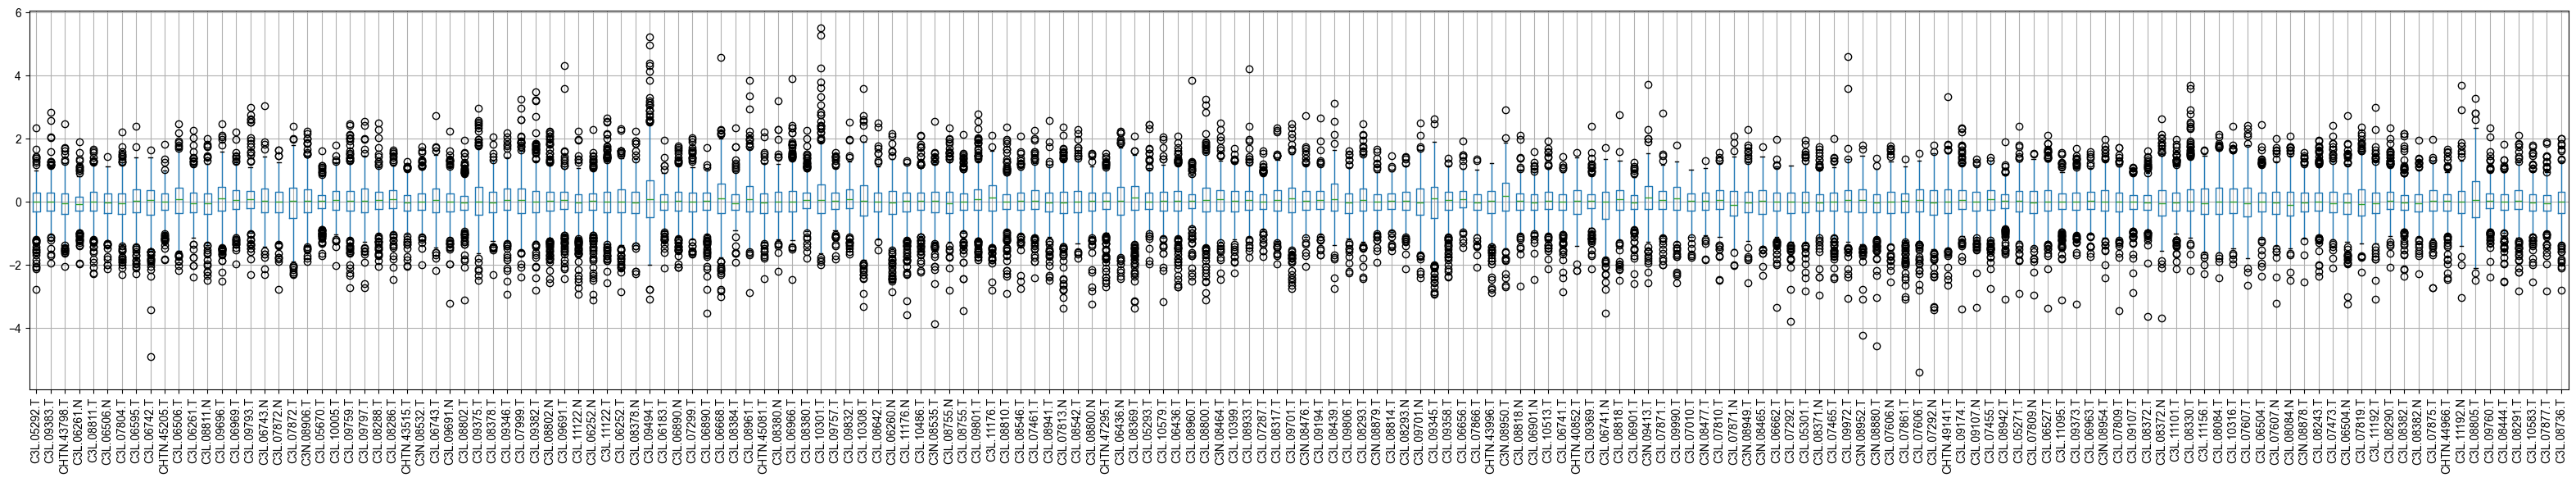

In [18]:
data.boxplot(figsize=(40,6), rot=90)

In [19]:
from omicsone_streamlit.plots.pca import plot_pca1

In [20]:
print(len(tumors_included), len(normals))

134 33


In [21]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = "Tumor"
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"

In [22]:
len(set(data.columns) & set(tumors_included))

134

In [23]:
data2 = data_nomiss.T.loc[tumors_included + normals,:]
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')

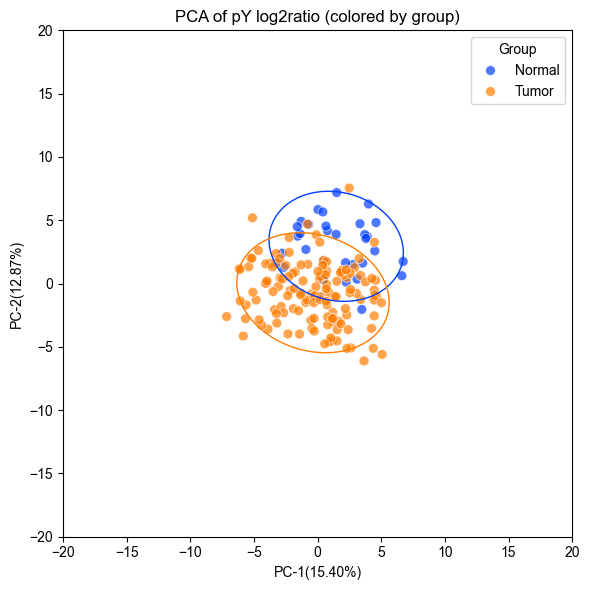

In [24]:
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=(-20,20), ylim=(-20,20), figsize=(6,6),
                    title="PCA of pY log2ratio (colored by group)")

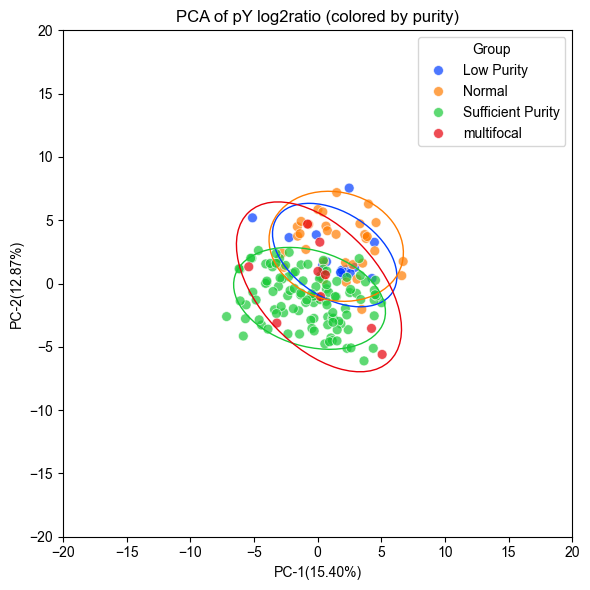

In [25]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = purity_map.get(i, "Tumor")
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=(-20,20), ylim=(-20,20), figsize=(6,6),
                    title="PCA of pY log2ratio (colored by purity)")

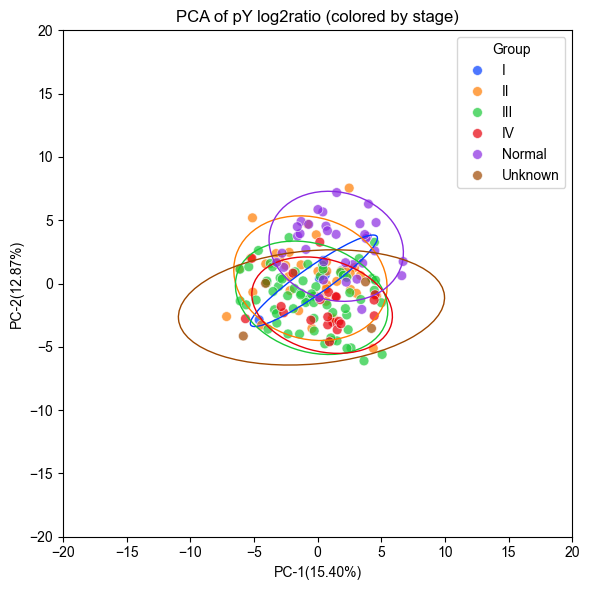

In [26]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = re.sub("[ABC]",'',stage_map.get(i, "Tumor"))
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=(-20,20), ylim=(-20,20), figsize=(6,6),
                    title="PCA of pY log2ratio (colored by stage)")

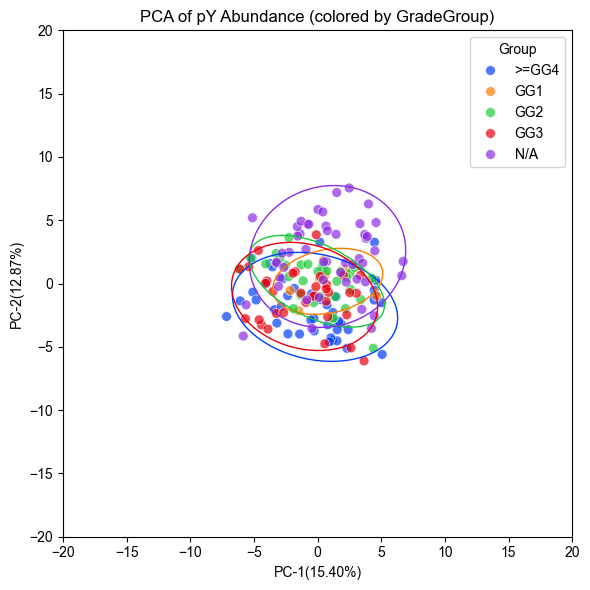

In [27]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = str(gleason_map.get(i, "N/A"))
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
for i in group_map:
    group_map[i] = 'N/A' if not re.search("GG", group_map[i]) else group_map[i]
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=(-20,20), ylim=(-20,20), figsize=(6,6),
                    title="PCA of pY Abundance (colored by GradeGroup)")